## Analytic Power Spectrum Calculation

Environment C correlation functions 

## Setup

In [4]:
%load_ext autoreload
%autoreload 2

import os, sys
import pickle
sys.path.append("../")
sys.path.append("../analytics/")


import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import numpy as np
from matplotlib.lines import Line2D


# Special functions for analytic calculations
from scipy.special import spherical_jn, hyp2f1
from scipy.interpolate import interp1d

# Dark photon perturbation theory code
grf_path = "/home/bakerem/dark-photons-perturbations"
sys.path.append(grf_path)

from grf.grf import PerturbedProbability, FIRAS
from grf.pk_interp import PowerSpectrumGridInterpolator
from grf.units import *

from low_mass_analyic_Cl import compute_Cls


from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

%matplotlib inline

# Custom plotting parameters
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_1004/1322806348.py:32: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


In [ ]:
# compute Cls using imported function, see the the file low_mass_analyic_Cl.py in the analytics directory
ls, Cls, thetas, xi = compute_Cls(3e-14)

/home/bakerem/dark_photon_21cm_constraints/notebooks_for_paper/../analytics/low_mass_analyic_Cl.py:269: RuntimeWarning: invalid value encountered in log1p
  X_ary = np.log1p(xi_ary)


In [ ]:
# load predicted xi from running tree corr on high resolution pyilc map, can regenerate these using the 21cmFAST_corr_funcs file
rnom, obs_xi = np.load("data/roman_mA3.000e-14_obs_auto_xi.npy")
obs_cov = np.load("data/roman_mA3.000e-14_obs_auto_cov.npy")

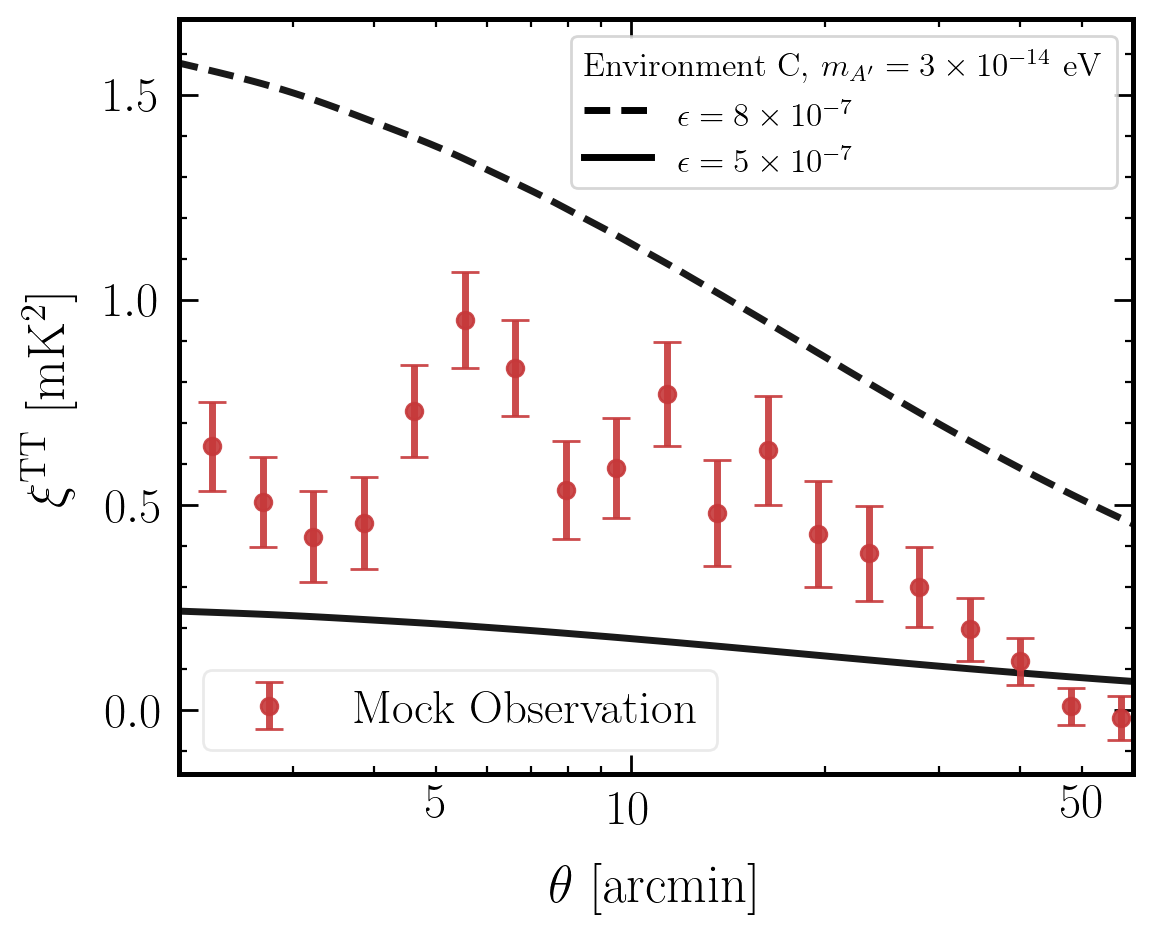

In [ ]:
epsilon_high = 8e-7
epsilon_low = 5e-7
new_prefac = 2 * np.pi * 410e6 * 6.58212e-16 # convert MHz to eV and normalizes to radio frequ

#plot in arcminutes 
plt.plot(np.rad2deg(thetas)*60, (2.73e3)**2 * (epsilon_high**4) * xi / new_prefac**2, ls="--", color="k")
plt.plot(np.rad2deg(thetas)*60, (2.73e3)**2 * (epsilon_low**4) * xi / new_prefac**2, ls="-", color="k")

plt.errorbar(np.rad2deg(rnom)*60, obs_xi /new_prefac**2, yerr=np.sqrt(np.diag(obs_cov))/new_prefac**2, color=cols_default[0], fmt='o', label="Mock Observation")
plt.legend()

plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\xi^{\rm TT}$ [mK$^2$]")
plt.xscale("log")
# Set major and minor ticks as before, but keep all original ticks
ax = plt.gca()
current_ticks = ax.get_xticks(minor=True)

theory_line = Line2D([0,1],[0,1],linestyle='--', color='k')
# Add labels at x=5 and x=50 while keeping existing minor ticks
new_minor_ticks = np.unique(np.append(current_ticks, [5.0, 50.0]))
ax.set_xticks(new_minor_ticks, minor=True)
minor_labels = [("5" if np.isclose(t, 5.0) else "50" if np.isclose(t, 50.0) else "") for t in new_minor_ticks]
ax.set_xticklabels(minor_labels, minor=True)
theory_line2 = Line2D([0,1],[0,1],linestyle='-', color='k')


legend2 = plt.legend([theory_line, theory_line2], [r"$\epsilon=8\times 10^{-7}$", r"$\epsilon=5\times 10^{-7}$"], 
                    loc="upper right", 
                    frameon=True, fontsize=12, title=r"Environment C, $m_{A'}=3\times 10^{-14}$ eV", title_fontsize=12, framealpha=0.8)
# legend2.set_title(r"Predicted Signal, $m_{A'}=5.6\times 10^{-13}$ eV")
plt.gca().add_artist(legend2)
legend2._legend_box.align = 'left'
plt.xlim(2, 60)
    
# legend1 = plt.legend(fontsize=12, frameon=True, 
#                      loc="lower left", 
#                      framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

plt.legend(loc="lower left", frameon=True)
plt.savefig("plots/analytic_xi_environmentC_mA3e-14.pdf", bbox_inches='tight')

